
# 13_sac_halfcheetah.ipynb — Phase 1 (SAC on HalfCheetah: PyBullet or MuJoCo)
**Soft Actor-Critic (SAC)** ile **HalfCheetah** eğitimi. Mac M1 Pro uyumlu akış: PyBullet öncelikli, açılamazsa MuJoCo denenir.

Bu defter şunları içerir:
- **SAC (SB3)** eğitimi (HalfCheetah *PyBullet* veya *MuJoCo*)
- Proje-özgü klasörler + **Monitor**
- **EvalCallback** (TensorBoard `eval/mean_reward`) + **Checkpoint**
- **progress.csv** ve **TensorBoard event** dosyalarından **grafikler**
- (Opsiyonel) **render demo**
- Kısa **SAC teori** notları


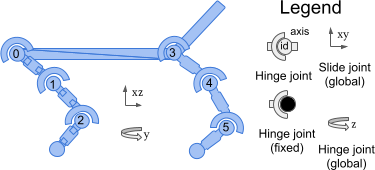
# Summary of HalfCheetah-v5 Environment Components

This is a quick reference for the HalfCheetah-v5 environment from Gymnasium, a classic benchmark for locomotion tasks in reinforcement learning. It's useful as a "toy" environment to prototype algorithms before moving to quadruped simulations.

## Action Space
- **Type:** Box(-1.0, 1.0, (6,), float32)
- **Description:** Actions represent normalized torques applied to the 6 hinge joints (back and front legs). Values are clipped between -1 and 1, scaled internally by MuJoCo to actual torques (e.g., ±150 Nm).

| Num | Action                          | Control Min | Control Max | Name (in XML) | Joint | Unit     |
|-----|---------------------------------|-------------|-------------|---------------|-------|----------|
| 0   | Torque on back thigh rotor     | -1         | 1          | bthigh       | hinge | torque (N m) |
| 1   | Torque on back shin rotor      | -1         | 1          | bshin        | hinge | torque (N m) |
| 2   | Torque on back foot rotor      | -1         | 1          | bfoot        | hinge | torque (N m) |
| 3   | Torque on front thigh rotor    | -1         | 1          | fthigh       | hinge | torque (N m) |
| 4   | Torque on front shin rotor     | -1         | 1          | fshin        | hinge | torque (N m) |
| 5   | Torque on front foot rotor     | -1         | 1          | ffoot        | hinge | torque (N m) |

## Observation Space
- **Type (Default):** Box(-Inf, Inf, (17,), float64)
- **Description:** Consists of 8 position values (qpos[1:], excluding root x-position to prevent exploitation) and 9 velocity values (qvel). If `exclude_current_positions_from_observation=False`, it becomes (18,) including root x-position. The root x- and y-positions are available in the `info` dict.

| Num | Observation                     | Min   | Max   | Name (in XML) | Joint | Unit                  |
|-----|---------------------------------|-------|-------|---------------|-------|-----------------------|
| 0   | z-coordinate of front tip      | -Inf | Inf  | rootz        | slide | position (m)         |
| 1   | Angle of front tip             | -Inf | Inf  | rooty        | hinge | angle (rad)          |
| 2   | Angle of back thigh            | -Inf | Inf  | bthigh       | hinge | angle (rad)          |
| 3   | Angle of back shin             | -Inf | Inf  | bshin        | hinge | angle (rad)          |
| 4   | Angle of back foot             | -Inf | Inf  | bfoot        | hinge | angle (rad)          |
| 5   | Angle of front thigh           | -Inf | Inf  | fthigh       | hinge | angle (rad)          |
| 6   | Angle of front shin            | -Inf | Inf  | fshin        | hinge | angle (rad)          |
| 7   | Angle of front foot            | -Inf | Inf  | ffoot        | hinge | angle (rad)          |
| 8   | Velocity of x-coordinate (tip) | -Inf | Inf  | rootx        | slide | velocity (m/s)       |
| 9   | Velocity of z-coordinate (tip) | -Inf | Inf  | rootz        | slide | velocity (m/s)       |
| 10  | Angular velocity of front tip  | -Inf | Inf  | rooty        | hinge | angular vel (rad/s)  |
| 11  | Angular velocity of back thigh | -Inf | Inf  | bthigh       | hinge | angular vel (rad/s)  |
| 12  | Angular velocity of back shin  | -Inf | Inf  | bshin        | hinge | angular vel (rad/s)  |
| 13  | Angular velocity of back foot  | -Inf | Inf  | bfoot        | hinge | angular vel (rad/s)  |
| 14  | Angular velocity of front thigh| -Inf | Inf  | fthigh       | hinge | angular vel (rad/s)  |
| 15  | Angular velocity of front shin | -Inf | Inf  | fshin        | hinge | angular vel (rad/s)  |
| 16  | Angular velocity of front foot | -Inf | Inf  | ffoot        | hinge | angular vel (rad/s)  |
| (excluded) | x-coordinate of front tip | -Inf | Inf  | rootx        | slide | position (m)         |

## Rewards
- **Total Reward Formula:** `reward = forward_reward - ctrl_cost`
- **Forward Reward:** Encourages forward movement: `forward_reward_weight * (x_position_after - x_position_before) / dt`
  - Default `forward_reward_weight = 1.0`
  - `dt` is the timestep (default: 0.05 s, based on frame_skip=5 and frametime=0.01 s)
  - Positive when moving right (positive x-direction); based on torso tip displacement.
- **Control Cost:** Penalizes large actions for energy efficiency: `ctrl_cost_weight * sum(action^2)`
  - Default `ctrl_cost_weight = 0.1`
- **Additional Notes:** Individual terms are in `info` dict. Relates to your thesis by balancing progress (locomotion) with control effort—useful for fault scenarios where degraded motors increase costs.

## 1) Kurulum

In [1]:

# PyBullet ile çalıştırmak genelde Mac M1'de en sorunsuz akış.
# Gerekirse etkinleştirin:
# %pip install -U "stable-baselines3>=2.3.0" gymnasium tensorboard pandas matplotlib tqdm pybullet pybullet_envs
#
# MuJoCo kullanacaksanız (opsiyonel; sisteminizde kurulum gerekebilir):
# %pip install mujoco "gymnasium[mujoco]"


## 2) Kütüphaneler ve Sürüm Bilgisi

In [2]:

import os, time, uuid, json, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import gymnasium as gym
import stable_baselines3 as sb3
from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.logger import configure
from stable_baselines3.common.utils import set_random_seed

print("Python         ", f"{os.sys.version.split()[0]}")
print("Gymnasium      ", gym.__version__)
print("SB3            ", sb3.__version__)
print("PyTorch        ", torch.__version__)
print("CUDA available ", torch.cuda.is_available())
print("MPS available  ", torch.backends.mps.is_available())
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device   ", device)

# PyBullet env'leri
try:
    import pybullet_envs  # noqa: F401
    HAVE_PYBULLET = True
except Exception:
    HAVE_PYBULLET = False
print("PyBullet envs  ", HAVE_PYBULLET)


Python          3.9.6
Gymnasium       1.1.1
SB3             2.6.0
PyTorch         2.7.1
CUDA available  False
MPS available   True
Using device    mps
PyBullet envs   False


## 3) Deney Ayarları ve Klasör Yapısı

In [3]:

PHASE    = "Phase 1"
STEP     = "SAC-HalfCheetah"
NOTEBOOK = "13_sac_halfcheetah"

# Öncelik: PyBullet -> MuJoCo (Mac uyumu)
CANDIDATE_ENVS = ["HalfCheetahBulletEnv-v0", "HalfCheetah-v5"]

SEED = 42
TOTAL_STEPS = 1_000_000    # isteğe göre artırılabilir (2-3M)
EVAL_FREQ   = 20_000
SAVE_FREQ   = 100_000

# SAC hiperparametreleri
SAC_CFG = dict(
    learning_rate=3e-4,
    buffer_size=1_000_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",                 # otomatik sıcaklık
    policy_kwargs=dict(net_arch=[256, 256])
)

RUN_ID    = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR  = os.path.join("runs", PHASE, NOTEBOOK, RUN_ID)
CKPT_DIR  = os.path.join(ROOT_DIR, "checkpoints")
MON_DIR   = os.path.join(ROOT_DIR, "monitor")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(MON_DIR,  exist_ok=True)

set_random_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print("ROOT_DIR:", ROOT_DIR)


ROOT_DIR: runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e


## 4) Ortam Kurulumu (PyBullet → MuJoCo otomatik seçim)

In [4]:

def make_halfcheetah_env(render=False, monitor=True):
    last_err = None
    for env_id in CANDIDATE_ENVS:
        try:
            if render:
                env = gym.make(env_id, render_mode="human")
            else:
                env = gym.make(env_id)
            if monitor:
                md = os.path.join(MON_DIR, env_id)
                os.makedirs(md, exist_ok=True)
                env = Monitor(env, md)
            print(f"[ENV] Using: {env_id}")
            return env, env_id
        except Exception as e:
            last_err = e
            print(f"[ENV] Failed to create {env_id}: {type(e).__name__} -> {e}")
    raise RuntimeError(f"Hiçbir HalfCheetah ortamı açılamadı. Son hata: {last_err}")

# Hızlı kontrol
env, active_env_id = make_halfcheetah_env(render=False, monitor=True)
obs, info = env.reset(seed=SEED)
print("Obs shape:", np.array(obs).shape, "| Act space:", env.action_space)
env.close()


[ENV] Failed to create HalfCheetahBulletEnv-v0: NameNotFound -> Environment `HalfCheetahBulletEnv` doesn't exist. Did you mean: `HalfCheetah`?
[ENV] Using: HalfCheetah-v5
Obs shape: (17,) | Act space: Box(-1.0, 1.0, (6,), float32)


## 5) Eğitim Fonksiyonu (SAC + Eval/Checkpoint + TensorBoard)

In [5]:

def train_sac_halfcheetah(total_steps=TOTAL_STEPS, seed=SEED):
    # Env & Eval Env
    env, env_id = make_halfcheetah_env(render=False, monitor=True)
    eval_env, _  = make_halfcheetah_env(render=False, monitor=False)

    log_dir = os.path.join(ROOT_DIR, env_id.replace("-", "_"))
    os.makedirs(log_dir, exist_ok=True)
    logger = configure(log_dir, ["stdout", "csv", "tensorboard"])

    model = SAC(
        policy="MlpPolicy",
        env=env,
        verbose=0,
        device="auto",
        seed=seed,
        **SAC_CFG
    )
    model.set_logger(logger)

    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=os.path.join(CKPT_DIR, env_id.replace("-", "_")),
        log_path=log_dir,
        eval_freq=EVAL_FREQ,
        n_eval_episodes=5,
        deterministic=True,
        render=False
    )
    ckpt_cb = CheckpointCallback(
        save_freq=SAVE_FREQ,
        save_path=os.path.join(CKPT_DIR, env_id.replace("-", "_")),
        name_prefix="ckpt"
    )

    model.learn(total_timesteps=total_steps, callback=[eval_cb, ckpt_cb], progress_bar=True)

    final_path = os.path.join(CKPT_DIR, env_id.replace("-", "_"), "final_sac.zip")
    os.makedirs(os.path.dirname(final_path), exist_ok=True)
    model.save(final_path)
    print("[DONE] Saved:", final_path)

    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
    print(f"[EVAL] {env_id} | MeanReturn={mean_r:.1f} ± {std_r:.1f}")

    env.close(); eval_env.close()
    return log_dir, env_id


## 6) Eğitimi Başlat

In [6]:

TB_DIR, ACTIVE_ENV = train_sac_halfcheetah()
print("TensorBoard dir:", TB_DIR)


[ENV] Failed to create HalfCheetahBulletEnv-v0: NameNotFound -> Environment `HalfCheetahBulletEnv` doesn't exist. Did you mean: `HalfCheetah`?
[ENV] Using: HalfCheetah-v5
[ENV] Failed to create HalfCheetahBulletEnv-v0: NameNotFound -> Environment `HalfCheetahBulletEnv` doesn't exist. Did you mean: `HalfCheetah`?
[ENV] Using: HalfCheetah-v5
Logging to runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e/HalfCheetah_v5


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -282     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 110      |
|    time_elapsed    | 36       |
|    total_timesteps | 4000     |
| train/             |          |
|    actor_loss      | -30.7    |
|    critic_loss     | 1.02     |
|    ent_coef        | 0.313    |
|    ent_coef_loss   | -11      |
|    learning_rate   | 0.0003   |
|    n_updates       | 3899     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -254     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 109      |
|    time_elapsed    | 73       |
|    total_timesteps | 8000     |
| train/             |          |
|    actor_loss      | -29.1    |
|    critic_loss     | 1.29     |
|    ent_coef        | 0.0997   |
|    ent_coef_loss   | -17.4    |
|    learning_rate   | 0.0003   |
|    n_updates       | 7899     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -228     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 108      |
|    time_elapsed    | 110      |
|    total_timesteps | 12000    |
| train/             |          |
|    actor_loss      | -21.4    |
|    critic_loss     | 0.695    |
|    ent_coef        | 0.0338   |
|    ent_coef_loss   | -15.9    |
|    learning_rate   | 0.0003   |
|    n_updates       | 11899    |
---------------------------------


...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 1.98e+03 |
| time/              |          |
|    episodes        | 996      |
|    fps             | 104      |
|    time_elapsed    | 9531     |
|    total_timesteps | 996000   |
| train/             |          |
|    actor_loss      | -163     |
|    critic_loss     | 0.607    |
|    ent_coef        | 0.0439   |
|    ent_coef_loss   | 1.06     |
|    learning_rate   | 0.0003   |
|    n_updates       | 995899   |
---------------------------------


Eval num_timesteps=1000000, episode_reward=2097.59 +/- 14.93

Episode length: 1000.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 1e+03    |
|    mean_reward     | 2.1e+03  |
| time/              |          |
|    total_timesteps | 1000000  |
| train/             |          |
|    actor_loss      | -164     |
|    critic_loss     | 0.433    |
|    ent_coef        | 0.0432   |
|    ent_coef_loss   | 0.232    |
|    learning_rate   | 0.0003   |
|    n_updates       | 999899   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 1.98e+03 |
| time/              |          |
|    episodes        | 1000     |
|    fps             | 104      |
|    time_elapsed    | 9572     |
|    total_timesteps | 1000000  |
---------------------------------


[DONE] Saved: runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e/checkpoints/HalfCheetah_v5/final_sac.zip
[EVAL] HalfCheetah-v5 | MeanReturn=2102.4 ± 12.5
TensorBoard dir: runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e/HalfCheetah_v5


## 7) progress.csv'den Öğrenme Eğrisi

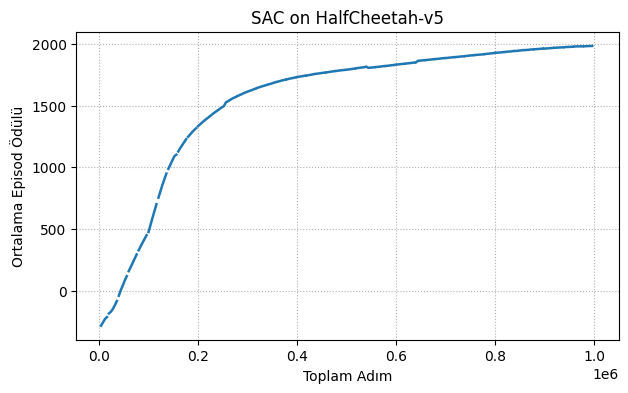

In [7]:

def plot_progress_csv(log_dir, title=None):
    csv_path = os.path.join(log_dir, "progress.csv")
    if not os.path.exists(csv_path):
        print("[WARN] progress.csv bulunamadı:", csv_path)
        return
    df = pd.read_csv(csv_path)
    tcol = next((c for c in ["time/total_timesteps","timesteps","total_timesteps"] if c in df.columns), None)
    rcol = next((c for c in ["rollout/ep_rew_mean","ep_rew_mean"] if c in df.columns), None)
    if not (tcol and rcol):
        print("[WARN] Gerekli kolonlar yok."); return
    plt.figure(figsize=(7,4))
    plt.plot(df[tcol].values, df[rcol].values, linewidth=1.8)
    plt.title(title or "SAC — Öğrenme Eğrisi")
    plt.xlabel("Toplam Adım")
    plt.ylabel("Ortalama Episod Ödülü")
    plt.grid(True, linestyle=":", linewidth=0.8)
    plt.show()

plot_progress_csv(TB_DIR, title=f"SAC on {ACTIVE_ENV}")


## 8) TensorBoard `eval/mean_reward` Çizimi

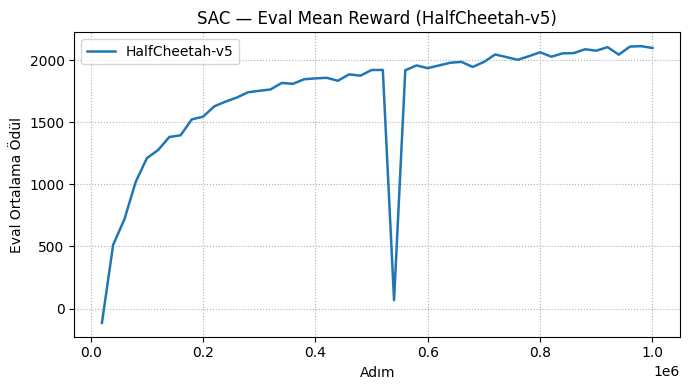

In [8]:

from tensorboard.backend.event_processing import event_accumulator as ea

def load_tb_scalar_series(run_dir: str, tag: str):
    files = []
    for root, _, fnames in os.walk(run_dir):
        for f in fnames:
            if f.startswith("events.out.tfevents"):
                files.append(os.path.join(root, f))
    if not files:
        return pd.DataFrame(columns=["step","value"])

    dfs = []
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7})
            acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                scal = acc.Scalars(tag)
                if scal:
                    steps = [s.step for s in scal]
                    vals  = [s.value for s in scal]
                    dfs.append(pd.DataFrame({"step": steps, "value": vals}))
        except Exception as ex:
            print("[WARN] TB dosyası okunamadı:", f, ex)
    if not dfs:
        return pd.DataFrame(columns=["step","value"])
    out = pd.concat(dfs, ignore_index=True).sort_values("step")
    out = out.groupby("step", as_index=False)["value"].mean()
    return out

df_eval = load_tb_scalar_series(TB_DIR, "eval/mean_reward")
if len(df_eval):
    plt.figure(figsize=(7,4))
    plt.plot(df_eval["step"].values, df_eval["value"].values, linewidth=1.8, label=ACTIVE_ENV)
    plt.title(f"SAC — Eval Mean Reward ({ACTIVE_ENV})")
    plt.xlabel("Adım")
    plt.ylabel("Eval Ortalama Ödül")
    plt.grid(True, linestyle=":", linewidth=0.8)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] 'eval/mean_reward' bulunamadı. EvalCallback çalışmış mı kontrol edin.")


## 9) Render Demo (İsteğe bağlı)

In [9]:

def render_demo_sac(env_id, ckpt_subdir=None, model_name="final_sac.zip", episodes=3):
    '''
    MuJoCo'da "human" penceresi, PyBullet'te GUI gerekebilir.
    Sunucusuz/CI ortamında çalışmayabilir. Lokal Mac'te deneyin.
    '''
    try:
        env = gym.make(env_id, render_mode="human")
    except TypeError:
        env = gym.make(env_id)  # bazı PyBullet sürümleri render_mode desteklemiyor

    path = os.path.join(CKPT_DIR, (ckpt_subdir or env_id.replace("-", "_")), model_name)
    if not os.path.exists(path):
        print("[WARN] Model bulunamadı:", path)
        env.close(); return

    model = SAC.load(path, env=env, device="auto")
    try:
        for ep in range(episodes):
            obs, _ = env.reset(seed=SEED+ep)
            done = truncated = False
            ret = 0.0
            while not (done or truncated):
                action, _ = model.predict(obs, deterministic=True)
                obs, r, done, truncated, _ = env.step(action)
                ret += r
            print(f"[RENDER] {env_id} | Episode {ep+1}: Return={ret:.1f}")
    finally:
        env.close()

# Örnek kullanım:
render_demo_sac(ACTIVE_ENV, ckpt_subdir=ACTIVE_ENV.replace("-","_"), model_name="final_sac.zip", episodes=3)


[RENDER] HalfCheetah-v5 | Episode 1: Return=2092.3
[RENDER] HalfCheetah-v5 | Episode 2: Return=2106.5
[RENDER] HalfCheetah-v5 | Episode 3: Return=2110.2



## 10) Teori — SAC Temelleri (defterlik notlar)

**Soft Actor-Critic (SAC)**, maksimum entropi RL çerçevesinde politika öğrenir:
- **Amaç:** Hem beklenen getiriyi **hem de** politika entropisini maksimize etmek.
- **Politika (Gaussian):** \(\pi_\theta(a|s)=\mathcal{N}(\mu_\theta(s), \sigma_\theta(s))\) (reparameterization).
- **İki Q ağı (double critic):** Overestimation'ı azaltmak için \(Q_{\phi_1}, Q_{\phi_2}\) kullanılır.
- **Hedefler:**  
  \[ y = r + \gamma \big(\min_i Q_{\phi_i^-}(s', a') - \alpha \log\pi_\theta(a'|s')\big) \]  
  burada \(a' \sim \pi_\theta(\cdot|s')\), \(\alpha\) sıcaklık (entropi katsayısı).
- **Otomatik sıcaklık (\(\alpha\)) ayarı:** `ent_coef="auto"` ile hedef entropiye göre ayarlanır.
- **Actor güncellemesi:**  
  \[ \nabla_\theta \mathbb{E}_{s \sim \mathcal{D}, a \sim \pi_\theta}\big[\alpha \log\pi_\theta(a|s) - \min_i Q_{\phi_i}(s,a)\big] \ ]

**Hiperparametre sezgisi:**
- `ent_coef="auto"` genellikle iyi; politika çok deterministik olursa \(\alpha\uparrow\), çok rastgele olursa \(\alpha\downarrow\).
- `batch_size=256`, `buffer_size=1e6`, `tau=0.005` HalfCheetah için yaygın başlangıçlar.
- İzlenecek TB metrikleri:
  - `rollout/ep_rew_mean`, `rollout/ep_len_mean`
  - `train/entropy_loss` (veya `ent_coef`), `train/qf_loss`, `train/policy_loss`
  - `train/learning_rate`, `time/iterations`


## 11) Meta Bilgi

In [10]:

meta = {
    "phase": PHASE,
    "step": STEP,
    "notebook": NOTEBOOK,
    "seed": SEED,
    "run_id": RUN_ID,
    "root_dir": ROOT_DIR,
    "ckpt_dir": CKPT_DIR,
    "monitor_dir": MON_DIR,
    "candidates": CANDIDATE_ENVS
}
os.makedirs(ROOT_DIR, exist_ok=True)
with open(os.path.join(ROOT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))


{
  "phase": "Phase 1",
  "step": "SAC-HalfCheetah",
  "notebook": "13_sac_halfcheetah",
  "seed": 42,
  "run_id": "20251003-192009-bc2a6e",
  "root_dir": "runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e",
  "ckpt_dir": "runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e/checkpoints",
  "monitor_dir": "runs/Phase 1/13_sac_halfcheetah/20251003-192009-bc2a6e/monitor",
  "candidates": [
    "HalfCheetahBulletEnv-v0",
    "HalfCheetah-v5"
  ]
}
